In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Load data
import pandas as pd

data = pd.read_csv(
    "PBMC_PerezScience2022.tsv",
    sep="\t",
    index_col=0  
)
X = data.values
print(data)   

# Check data is numeric
print(data.dtypes.unique())   # should be float

# Check for NaNs
print("Total NaNs:", data.isna().sum().sum())

                                                    AL627309.1  LINC00115  \
CTTCTCTTCCTTTCTC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
CTCAGAAAGATAGCAT-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
CTCGAAAAGGTGCAAC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
GTGCATACATCGGAAG-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
CACAGTACACGTTGGC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
...                                                        ...        ...   
AGGCCGTTCATGTGGT-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
AAGGAGCTCCGTACAA-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
AGCTTGAAGTTGCAGG-1-1-0-0-0-0-0-0-0-0-0-0-1-0               0.0        0.0   
ATCATGGTCAGTGCAT-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   
GCATGTACAATACGCT-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-...         0.0        0.0   

                                                    FAM41C       HES4  \
CT

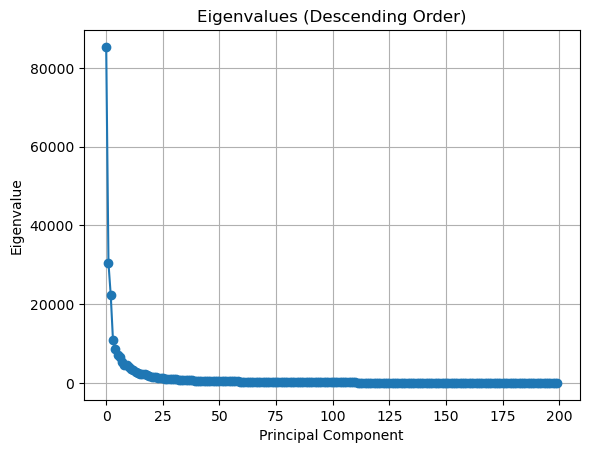

In [26]:
# 1(a) hint: 
# - np.linalg.eigh can perform more stable eigenvalue decomposition for symmetrical matrices
# - eigenvalues from np.linalg.eigh organize eigenvalues in ascending order
# begin solution

# Center the data
X_centered = X - np.mean(X, axis=0)

# Covariance matrix (K x K)
S = np.cov(X_centered, rowvar=False)

# Eigendecomposition (ascending order)
eigenvalues, eigenvectors = np.linalg.eigh(S)

# Sort in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Plot eigenvalues
plt.figure()
plt.plot(eigenvalues, marker='o')
plt.title("Eigenvalues (Descending Order)")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

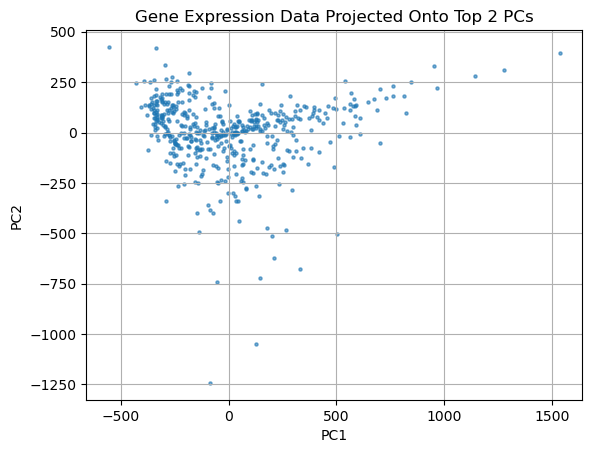

PC1 range: 2093.3703795007377
PC2 range: 1667.841685950583


In [31]:
# 1(c) 
# - which eigenvectors to use?
# - how to project data onto eigenvectors
# - does PC1 or PC2 have a large dynamic range?
# begin solution

# Select top 2 eigenvectors
W = eigenvectors[:, :2]

# Project data
X_proj = X_centered @ W

# Scatter plot
plt.figure()
plt.scatter(X_proj[:, 0], X_proj[:, 1], s=5, alpha=0.6)
plt.title("Gene Expression Data Projected Onto Top 2 PCs")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

# Check dynamic range
print("PC1 range:", X_proj[:, 0].max() - X_proj[:, 0].min())
print("PC2 range:", X_proj[:, 1].max() - X_proj[:, 1].min())
# end solution

In [30]:
# 1(d)
# - How many principal components are needed to explain at least 90% of the total variance?
#      Print your answer.
# begin solution

# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Find minimum number of components for >= 90%
num_components = np.argmax(cumulative_variance >= 0.90) + 1

print("Number of components for at least 90% variance:", num_components)
# end solution

Number of components for at least 90% variance: 36
